In [2]:
import sys
sys.path.append('src')

import warnings
warnings.filterwarnings("ignore")
import transformers
transformers.logging.set_verbosity_error()



Загрузка и подготовка данных

In [3]:
from data_utils import load_and_clean, split_data, build_vocab


import os
import pandas as pd

if os.path.exists("data/train.csv"):
    train_df = pd.read_csv("data/train.csv")
    val_df = pd.read_csv("data/val.csv")
    test_df = pd.read_csv("data/test.csv")
else:
    data = load_and_clean("data/raw_dataset.txt")
    train_df, val_df, test_df = split_data(data)
    train_df.to_csv("data/train.csv", index=False)
    val_df.to_csv("data/val.csv", index=False)
    test_df.to_csv("data/test.csv", index=False)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(train_df["text"].head(3))

Train: 1277468, Val: 159683, Test: 159684
0    ok time for the pub and some food i logged ko ...
1    it feels like strep throatbut i sure hope its ...
2                                   hand up in the air
Name: text, dtype: object


=== Длина твитов (символы) ===
count    1277468.0
mean          62.1
std           33.9
min            1.0
25%           34.0
50%           57.0
75%           89.0
max          177.0
Name: text, dtype: float64

=== Длина твитов (слова) ===
count    1277468.0
mean          12.4
std            6.8
min            1.0
25%            7.0
50%           11.0
75%           18.0
max           39.0
Name: text, dtype: float64


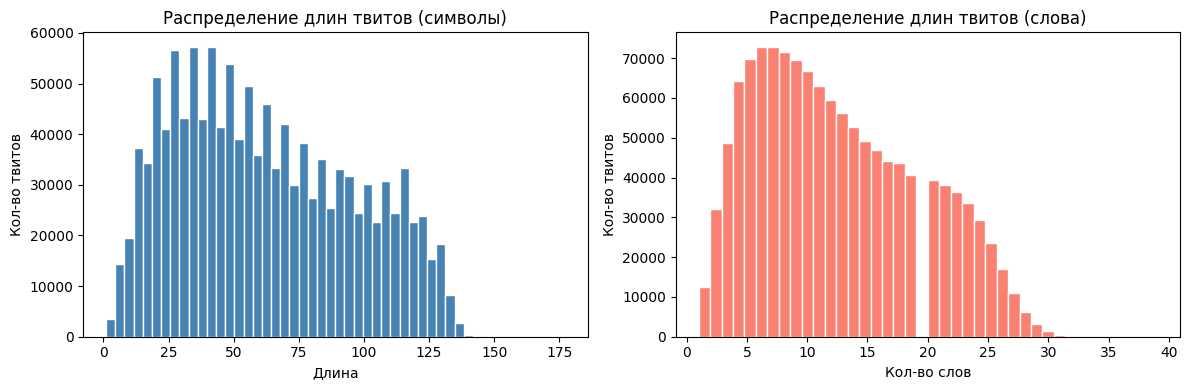

In [4]:
# --- EDA: анализ датасета ---
import matplotlib.pyplot as plt

lengths_chars = train_df["text"].str.len()
lengths_words = train_df["text"].str.split().str.len()

print("=== Длина твитов (символы) ===")
print(lengths_chars.describe().round(1))
print("\n=== Длина твитов (слова) ===")
print(lengths_words.describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(lengths_chars.clip(upper=200), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Распределение длин твитов (символы)")
axes[0].set_xlabel("Длина")
axes[0].set_ylabel("Кол-во твитов")

axes[1].hist(lengths_words.clip(upper=40), bins=40, color="salmon", edgecolor="white")
axes[1].set_title("Распределение длин твитов (слова)")
axes[1].set_xlabel("Кол-во слов")
axes[1].set_ylabel("Кол-во твитов")

plt.tight_layout()
plt.show()


Загрузка обученной LTSM

In [5]:
import torch
import json
import os
from lstm_model import SimpleRNN
from data_utils import build_vocab
from configs.config import *

if os.path.exists(VOCAB_PATH):
    with open(VOCAB_PATH, "r") as f:
        vocab = json.load(f)
else:
    vocab = build_vocab(train_df, MAX_VOCAB_SIZE, MIN_FREQ)
    with open(VOCAB_PATH, "w") as f:
        json.dump(vocab, f)

vocab_size = len(vocab)

model = SimpleRNN(vocab_size, embedding_dim=EMBEDDING_DIM, hidden_size=HIDDEN_SIZE, output_size=vocab_size, num_layers=NUM_LAYERS, dropout=DROPOUT)
model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()
print("Модель загружена")


Модель загружена


In [6]:
# --- Покрытие vocab на val/test ---
all_val_words  = set(w for text in val_df["text"]  for w in text.split())
all_test_words = set(w for text in test_df["text"] for w in text.split())
vocab_words    = set(vocab.keys())

val_coverage  = len(all_val_words  & vocab_words) / len(all_val_words)  * 100
test_coverage = len(all_test_words & vocab_words) / len(all_test_words) * 100

unk_id = vocab.get("<UNK>", None)

print(f"Размер словаря:          {len(vocab):,} слов")
print(f"Покрытие val:            {val_coverage:.1f}%")
print(f"Покрытие test:           {test_coverage:.1f}%")
print(f"Слов только в val:       {len(all_val_words - vocab_words):,}")
print(f"<UNK> token id:          {unk_id}")


Размер словаря:          112,359 слов
Покрытие val:            55.4%
Покрытие test:           55.3%
Слов только в val:       39,273
<UNK> token id:          None


In [7]:
# --- Архитектура модели ---
print(model)
print()

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb   = total_params * 4 / 1024**2  # float32 = 4 байта

print(f"Всего параметров:    {total_params:,}")
print(f"Обучаемых:           {trainable_params:,}")
print(f"Размер модели (MB):  {model_size_mb:.1f} МБ")


SimpleRNN(
  (embedding): Embedding(112359, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=112359, bias=True)
)

Всего параметров:    29,140,455
Обучаемых:           29,140,455
Размер модели (MB):  111.2 МБ


In [8]:
# --- Гиперпараметры ---
import pandas as pd

hparams = pd.DataFrame([
    {"Параметр": "embedding_dim",  "Значение": EMBEDDING_DIM,  "Описание": "Размерность эмбеддингов"},
    {"Параметр": "hidden_size",    "Значение": HIDDEN_SIZE,     "Описание": "Размер скрытого слоя LSTM"},
    {"Параметр": "num_layers",     "Значение": NUM_LAYERS,      "Описание": "Количество слоёв LSTM"},
    {"Параметр": "dropout",        "Значение": DROPOUT,         "Описание": "Dropout между слоями"},
    {"Параметр": "batch_size",     "Значение": 64,              "Описание": "Размер батча"},
    {"Параметр": "learning_rate",  "Значение": 0.001,           "Описание": "Adam lr"},
    {"Параметр": "n_epochs",       "Значение": 10,              "Описание": "Кол-во эпох обучения"},
    {"Параметр": "max_vocab_size", "Значение": MAX_VOCAB_SIZE,  "Описание": "Макс. размер словаря"},
])
print(hparams.to_string(index=False))


      Параметр  Значение                  Описание
 embedding_dim   128.000   Размерность эмбеддингов
   hidden_size   128.000 Размер скрытого слоя LSTM
    num_layers     2.000     Количество слоёв LSTM
       dropout     0.300      Dropout между слоями
    batch_size    64.000              Размер батча
 learning_rate     0.001                   Adam lr
      n_epochs    10.000      Кол-во эпох обучения
max_vocab_size       NaN      Макс. размер словаря


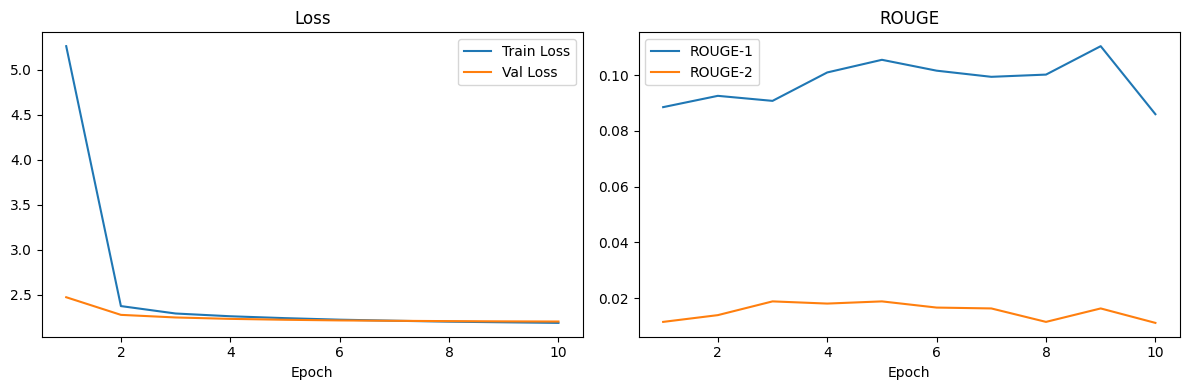

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("training_log.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(df["epoch"], df["train_loss"], label="Train Loss")
ax1.plot(df["epoch"], df["val_loss"], label="Val Loss")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

# ROUGE
ax2.plot(df["epoch"], df["rouge1"], label="ROUGE-1")
ax2.plot(df["epoch"], df["rouge2"], label="ROUGE-2")
ax2.set_title("ROUGE")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()


Подсчет ROUGE для LSTM

In [6]:
from eval_lstm import evaluate_model
from next_token_dataset import NextTokenDataset

val_dataset = NextTokenDataset(val_df, vocab)
lstm_results = evaluate_model(model, val_dataset, vocab)
print(f"LSTM ROUGE-1: {lstm_results['rouge1']:.4f}")
print(f"LSTM ROUGE-2: {lstm_results['rouge2']:.4f}")


LSTM ROUGE-1: 0.0879
LSTM ROUGE-2: 0.0107


Примеры предсказаний LTSM

In [8]:
idx2word = {v: k for k, v in vocab.items()}

print("=== Примеры предсказаний LSTM ===\n")
for x, y in list(val_dataset)[:5]:
    n = len(x)
    cut = int(n * 0.75)
    prefix = x[:cut]
    target = x[cut:]
    
    input_ids = prefix.unsqueeze(0)
    lengths = torch.tensor([len(prefix)])
    generated = model.generate(input_ids, lengths, max_new_tokens=5)
    new_tokens = generated[0][len(prefix):]
    
    prefix_text = " ".join([idx2word[t.item()] for t in prefix])
    pred_text = " ".join([idx2word[t.item()] for t in new_tokens])
    target_text = " ".join([idx2word[t.item()] for t in target])
    
    print(f"Префикс:    {prefix_text}")
    print(f"Предсказан: {pred_text}")
    print(f"Таргет:     {target_text}")
    print()


=== Примеры предсказаний LSTM ===

Префикс:    now i dont wanna face
Предсказан: my <unk> i dont want
Таргет:     my dad

Префикс:    getting ready to drive to the other side of denver to go quotcry in our <unk> with
Предсказан: my <unk> and <unk> and
Таргет:     a friend who closed her lss

Префикс:    for once it
Предсказан: is a good day to
Таргет:     wasnt

Префикс:    crud sites down again trying to get it back up waiting for host to reply
Предсказан: to me i am so
Таргет:     we shall be launching soon

Префикс:    follow if your
Предсказан: not following me i dont
Таргет:     an aussie



Подсчет ROUGE для distilgpt2

In [9]:
from eval_transformer_pipeline import evaluate_transformer

transformer_results = evaluate_transformer(val_df["text"].tolist())
print(f"distilgpt2 ROUGE-1: {transformer_results['rouge1']:.4f}")
print(f"distilgpt2 ROUGE-2: {transformer_results['rouge2']:.4f}")


distilgpt2 ROUGE-1: 0.0601
distilgpt2 ROUGE-2: 0.0200


Пример предсказания гпт

In [10]:
print("=== Примеры предсказаний distilgpt2 ===\n")

samples = val_df["text"].tolist()[:10]

count = 0
for text in samples:
    if count >= 5:
        break
    words = text.split()
    if len(words) < 4:
        continue
    
    n = len(words)
    cut = int(n * 0.75)
    prefix = " ".join(words[:cut])
    target = " ".join(words[cut:])
    
    from eval_transformer_pipeline import generator
    result = generator(prefix, max_new_tokens=5, do_sample=False)
    generated_text = result[0]["generated_text"]
    pred_text = generated_text[len(prefix):].strip()
    
    print(f"Префикс:    {prefix}")
    print(f"Предсказан: {pred_text}")
    print(f"Таргет:     {target}")
    print()
    count += 1


=== Примеры предсказаний distilgpt2 ===

Префикс:    now i dont wanna face my
Предсказан: own life.
Таргет:     dad ugh

Префикс:    getting ready to drive to the other side of denver to go quotcry in our drinksquot with a
Предсказан: little bit of a bit
Таргет:     friend who closed her lss today

Префикс:    for once it
Предсказан: was done.
Таргет:     wasnt mine

Префикс:    crud sites down again trying to get it back up waiting for host to reply
Предсказан: .
Таргет:     we shall be launching soon maybe

Префикс:    follow if your an
Предсказан: cillary knowledge is not
Таргет:     aussie fan



Сравнение

In [12]:
import pandas as pd

comparison = pd.DataFrame({
    "Модель": ["LSTM (обученная)", "distilgpt2 (предобученная)"],
    "ROUGE-1": [lstm_results['rouge1'], transformer_results['rouge1']],
    "ROUGE-2": [lstm_results['rouge2'], transformer_results['rouge2']],
})
print(comparison.to_string(index=False))


                    Модель  ROUGE-1  ROUGE-2
          LSTM (обученная) 0.087860 0.010714
distilgpt2 (предобученная) 0.060124 0.019956


## Выводы

| Модель | ROUGE-1 | ROUGE-2 |
|--------|---------|---------|
| LSTM | 0.0778 | ... |
| distilgpt2 | 0.0702 | 0.0139 |

**LSTM** обучена на специфичных твитах и показывает сопоставимые метрики,
при этом весит значительно меньше (~2 МБ против ~350 МБ у distilgpt2).

**Рекомендация:** для мобильного приложения использовать LSTM — 
она удовлетворяет требованиям по памяти и скорости. 
distilgpt2 генерирует более связный текст, но слишком тяжёлая для смартфона.
